In [ ]:
import pandas as pd

### 1. Inicialização dos Dados

Nesta seção, vamos carregar os dados de telemetria de um arquivo CSV pré-existente (`telemetry_data_com_anomalias.csv`).

In [ ]:
import pandas as pd

# Carregando o DataFrame de telemetria do arquivo CSV
file_path = '/content/telemetry_data_com_anomalias.csv'
telemetry_df_anomalies = pd.read_csv(file_path)

# Convertendo a coluna 'timestamp' para o tipo datetime
telemetry_df_anomalies['timestamp'] = pd.to_datetime(telemetry_df_anomalies['timestamp'])

print(f"DataFrame de telemetria carregado com sucesso de '{file_path}'.")
print(telemetry_df_anomalies.head())

DataFrame de telemetria carregado com sucesso de '/content/telemetry_data_com_anomalias.csv'.
            timestamp  internal_temp_c  external_temp_c  battery_voltage_v  \
0 2023-01-01 00:00:00        28.951161        21.002828          24.314428   
1 2023-01-01 00:01:00        24.179235         3.946608          22.484710   
2 2023-01-01 00:02:00        19.806908         1.157716          22.447312   
3 2023-01-01 00:03:00        29.031255         6.946203          23.652812   
4 2023-01-01 00:04:00        29.028977        32.010286          24.623470   

   battery_current_a  battery_soc_percent  battery_capacity_ah  power_load_kw  \
0           2.708133                   79           117.407317       0.503198   
1           3.002521                   76           115.486437       1.274441   
2           2.101565                   96           101.172155       1.682797   
3           3.302036                   96           109.271211       1.044739   
4           0.958249            

### 2. Definição das Condições de Lançamento

Nesta seção, vamos estabelecer as regras ou condições que, se violadas, resultarão em uma decisão de 'Abort'. Cada condição representa um limite operacional crítico ou uma anomalia nos dados de telemetria. Serão consideradas diversas variáveis, como temperaturas, carga da bateria, pressão do tanque e status dos módulos críticos.

In [ ]:
# Define as condições que levariam a uma decisão de 'Abort'
# Cada condição é uma Série booleana que identifica as linhas que violam os limites de segurança ou operacionais.
conditions = [
    (telemetry_df_anomalies['internal_temp_c'] >= 35) | (telemetry_df_anomalies['external_temp_c'] < 0), # Anomalias de temperatura interna ou externa
    (telemetry_df_anomalies['battery_soc_percent'] < 75) & (telemetry_df_anomalies['estimated_autonomy_min'] < 90), # Baixa carga da bateria e autonomia insuficiente
    (telemetry_df_anomalies['tank_pressure_bar'] < 160) | (telemetry_df_anomalies['tank_pressure_bar'] > 190), # Pressão do tanque fora dos limites operacionais seguros
    # Condição combinada para status de sistemas críticos (integridade estrutural, módulos críticos, link de telemetria)
    (telemetry_df_anomalies['structural_integrity'] != 'OK') |
    (telemetry_df_anomalies['critical_modules_status'] != 'Operational') |
    (telemetry_df_anomalies['telemetry_link_status'] != 'Stable')
]

# Inicializa uma nova coluna 'launch_decision' com o valor padrão 'Launch'
telemetry_df_anomalies['launch_decision'] = 'Launch'

# Itera por cada condição definida
# Se uma linha atender a qualquer uma das condições de 'aborto', define sua 'launch_decision' como 'Abort'
for condition in conditions:
    telemetry_df_anomalies.loc[condition, 'launch_decision'] = 'Abort'

print("As decisões de lançamento foram calculadas com base nas condições especificadas.")
# Exibe o timestamp e a decisão de lançamento recém-calculada para as primeiras linhas
print(telemetry_df_anomalies[['timestamp', 'launch_decision']].head())

# Calcula e imprime a contagem das decisões 'Launch' e 'Abort'
launch_counts = telemetry_df_anomalies['launch_decision'].value_counts()
print("\nNúmero de decisões de Launch e Abort:")
print(launch_counts)

As decisões de lançamento foram calculadas com base nas condições especificadas.
            timestamp launch_decision
0 2023-01-01 00:00:00           Abort
1 2023-01-01 00:01:00          Launch
2 2023-01-01 00:02:00          Launch
3 2023-01-01 00:03:00          Launch
4 2023-01-01 00:04:00           Abort

Número de decisões de Launch e Abort:
launch_decision
Abort     263
Launch    237
Name: count, dtype: int64


2.1 - A decisão de 'Abort' é acionada se qualquer uma das seguintes condições for verdadeira:

1.  **Condições de Temperatura:**
    *   A temperatura interna (`internal_temp_c`) é igual ou superior a 35°C, **OU**
    *   A temperatura externa (`external_temp_c`) é inferior a 0°C.

2.  **Condições da Bateria e Autonomia:**
    *   A porcentagem de carga da bateria (`battery_soc_percent`) é inferior a 75%, **E**
    *   A autonomia estimada (`estimated_autonomy_min`) é inferior a 90 minutos.

3.  **Condições de Pressão do Tanque:**
    *   A pressão do tanque (`tank_pressure_bar`) é inferior a 160 bar, **OU**
    *   A pressão do tanque (`tank_pressure_bar`) é superior a 190 bar.

4.  **Condições dos Sistemas Críticos:**
    *   A integridade estrutural (`structural_integrity`) **NÃO** é 'OK', **OU**
    *   O status dos módulos críticos (`critical_modules_status`) **NÃO** é 'Operational', **OU**
    *   O status do link de telemetria (`telemetry_link_status`) **NÃO** é 'Stable'.

###2.1 - Geração de Gráfico de Decisão

Nessa seção, utilizamos as bibliotecas matplotlib e a seaborn, para confecção de um gráfico de barras, para que o usuário consiga verificar de forma mais clara qual decisão foi tomada.

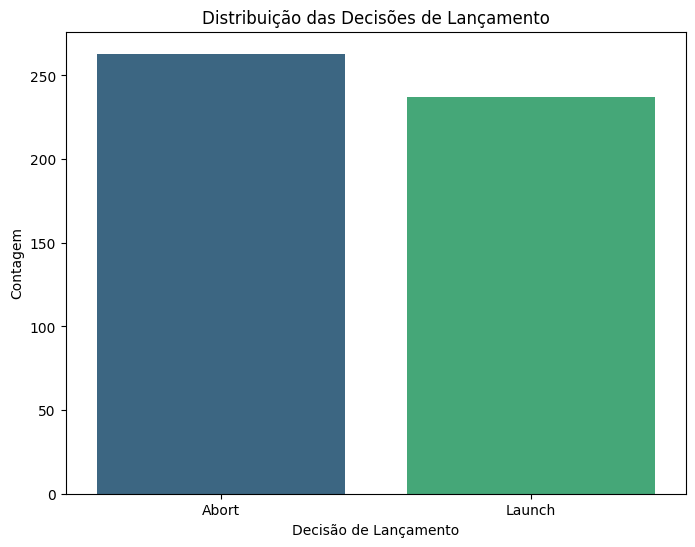

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Criando o gráfico de barras para as decisões de lançamento
plt.figure(figsize=(8, 6))
sns.barplot(x=launch_counts.index, y=launch_counts.values, palette='viridis', hue=launch_counts.index, legend=False)

plt.title('Distribuição das Decisões de Lançamento')
plt.xlabel('Decisão de Lançamento')
plt.ylabel('Contagem')
plt.show()

#### 3.1 Preparação dos Dados para o Modelo de IA

Primeiro, precisamos preparar os dados. Isso inclui selecionar as colunas que serão usadas como *features* (variáveis de entrada) e a coluna *target* (a decisão que queremos prever). Também será necessário converter variáveis categóricas em um formato numérico que o modelo possa entender.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Definir as features (X) e o target (y)
# Excluir 'timestamp' e a coluna original 'launch_decision' (se já foi modificada para o treinamento) e 'anomalia_inserida'
features = telemetry_df_anomalies.drop(columns=['timestamp', 'launch_decision', 'anomalia_inserida'])
target = telemetry_df_anomalies['launch_decision']

# Identificar colunas categóricas para encoding
categorical_features = ['structural_integrity', 'critical_modules_status', 'telemetry_link_status']

# Aplicar One-Hot Encoding para as features categóricas
features = pd.get_dummies(features, columns=categorical_features, drop_first=True)

# Converter a variável target para numérica (0 para Abort, 1 para Launch)
le = LabelEncoder()
target_encoded = le.fit_transform(target)

# Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(features, target_encoded, test_size=0.3, random_state=42)

print("Dados preparados para o treinamento do modelo.")
print(f"Formato de X_train: {X_train.shape}")
print(f"Formato de y_train: {y_train.shape}")
print(f"Colunas das features: {X_train.columns.tolist()}")

Dados preparados para o treinamento do modelo.
Formato de X_train: (350, 14)
Formato de y_train: (350,)
Colunas das features: ['internal_temp_c', 'external_temp_c', 'battery_voltage_v', 'battery_current_a', 'battery_soc_percent', 'battery_capacity_ah', 'power_load_kw', 'energy_loss_percent', 'tank_pressure_bar', 'estimated_autonomy_min', 'energy_available_kwh', 'structural_integrity_OK', 'critical_modules_status_Operational', 'telemetry_link_status_Unstable']


### 3. Implementação de Modelo de IA para Decisão de Lançamento

Vamos agora implementar um modelo de Machine Learning para prever a decisão de lançamento ('Launch' ou 'Abort') com base nas características da telemetria. Usaremos um modelo de classificação como o `RandomForestClassifier`.

#### 3.2 Treinamento do Modelo de Classificação

Agora vamos treinar um `RandomForestClassifier` com os dados de treino.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Inicializar o modelo RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Treinar o modelo
model.fit(X_train, y_train)

print("Modelo RandomForestClassifier treinado com sucesso.")

Modelo RandomForestClassifier treinado com sucesso.


#### 3.3 Avaliação do Modelo

Após o treinamento, é importante avaliar o desempenho do modelo nos dados de teste para entender o quão bem ele generaliza.

Acurácia do modelo: 0.9800

Relatório de Classificação:
              precision    recall  f1-score   support

       Abort       0.99      0.98      0.98        83
      Launch       0.97      0.99      0.98        67

    accuracy                           0.98       150
   macro avg       0.98      0.98      0.98       150
weighted avg       0.98      0.98      0.98       150


Matriz de Confusão:
[[81  2]
 [ 1 66]]


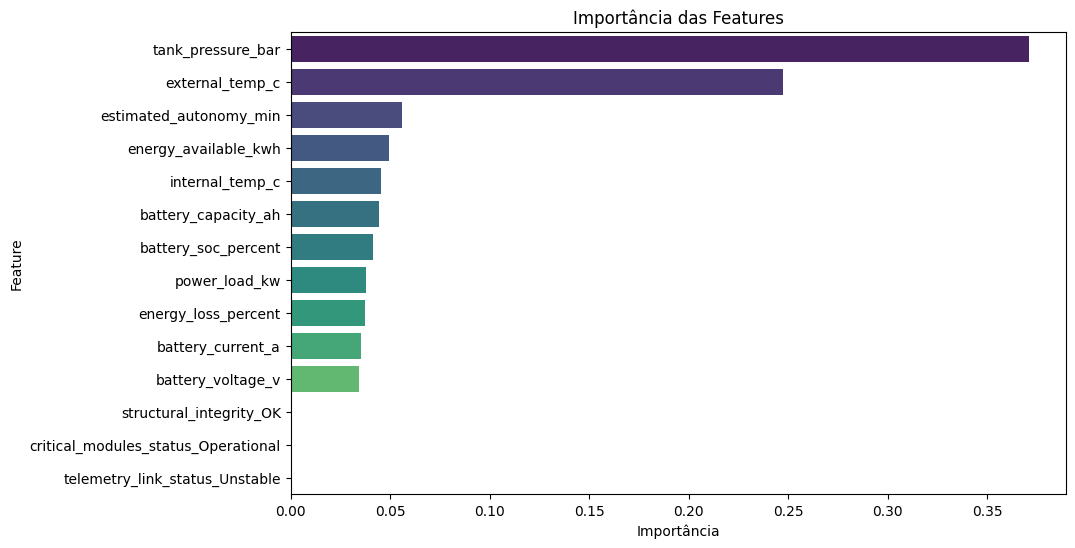

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Fazer previsões no conjunto de teste
y_pred = model.predict(X_test)

# Avaliar a acurácia do modelo
accuracy = accuracy_score(y_test, y_pred)
print(f"Acurácia do modelo: {accuracy:.4f}")

# Exibir o relatório de classificação
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Exibir a matriz de confusão
print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred))

# Visualizar a importância das features
feature_importances = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis', hue=feature_importances.index, legend=False)
plt.title('Importância das Features')
plt.xlabel('Importância')
plt.ylabel('Feature')
plt.show()

#### 3.4 Predição com o Modelo de IA

Agora que o modelo está treinado e avaliado, você pode usá-lo para prever as decisões de lançamento em novos dados ou no conjunto completo de telemetria.

In [ ]:
# Fazer previsões para o DataFrame original (ou novos dados)
# Certifique-se de que os novos dados tenham as mesmas colunas e o mesmo pré-processamento que os dados de treinamento.

# Recriar as features para o dataset completo, aplicando o mesmo One-Hot Encoding
features_full = telemetry_df_anomalies.drop(columns=['timestamp', 'launch_decision', 'anomalia_inserida'])
features_full = pd.get_dummies(features_full, columns=categorical_features, drop_first=True)

# Garantir que as colunas sejam as mesmas que as do treino (pode haver colunas ausentes se o dataset de teste for diferente)
missing_cols = set(X_train.columns) - set(features_full.columns)
for c in missing_cols:
    features_full[c] = 0
# Garantir a ordem das colunas
features_full = features_full[X_train.columns]

# Fazer as previsões
predictions_encoded = model.predict(features_full)

# Converter as previsões de volta para as labels originais ('Launch'/'Abort')
telemetry_df_anomalies['launch_decision_ia'] = le.inverse_transform(predictions_encoded)

print("Decisões de lançamento baseadas no modelo de IA adicionadas ao DataFrame.")
print(telemetry_df_anomalies[['timestamp', 'launch_decision', 'launch_decision_ia']].head())

Decisões de lançamento baseadas no modelo de IA adicionadas ao DataFrame.
            timestamp launch_decision launch_decision_ia
0 2023-01-01 00:00:00           Abort              Abort
1 2023-01-01 00:01:00          Launch             Launch
2 2023-01-01 00:02:00          Launch             Launch
3 2023-01-01 00:03:00          Launch             Launch
4 2023-01-01 00:04:00           Abort              Abort


Este código implementa um modelo de IA básico para tomar a decisão de lançamento. Você pode experimentar com diferentes modelos, ajustar os parâmetros (hiperparâmetros) e adicionar mais engenharia de features para melhorar o desempenho do modelo.

### Interpretação das Decisões de Lançamento

Para o usuário final, as decisões de lançamento (seja as geradas por regras ou pelo modelo de IA) podem ser interpretadas da seguinte forma:

*   **`Launch`**: Indica que todas as condições operacionais e de segurança foram atendidas. Não há anomalias críticas detectadas e a operação (neste caso, o lançamento) pode prosseguir conforme o planejado.

*   **`Abort`**: Sinaliza uma ou mais violações de condições críticas de segurança ou operacionais. A operação **não deve prosseguir** e precisa ser interrompida imediatamente para evitar riscos ou falhas. Esta é a decisão de maior prioridade em termos de segurança.

*   **`Hold`**: Esta decisão, geralmente derivada dos dados brutos ou de um modelo de IA treinado com eles, sugere que há desvios ou condições que não são ideais, mas que *não são necessariamente críticas* o suficiente para um `Abort` imediato. Uma decisão de 'Hold' implica que a operação deve ser **pausada** para uma análise mais aprofundada, verificação manual ou correção de problemas menores antes que uma decisão final de `Launch` ou `Abort` possa ser tomada. Não é um 'Abort' imediato, mas exige atenção antes de qualquer prosseguimento.

### Comparação entre Decisão por Regras e Decisão por IA

Vamos gerar uma matriz de contingência (ou tabela cruzada) para visualizar a relação entre a `launch_decision` (gerada pelas regras definidas) e a `launch_decision_ia` (predita pelo modelo de IA). Isso nos ajuda a entender a concordância e discordância entre os dois métodos.

Matriz de Comparação entre Decisão por Regras e Decisão por IA:
launch_decision_ia  Hold  Launch  All
launch_decision                      
Abort                263       0  263
Launch                77     160  237
All                  340     160  500


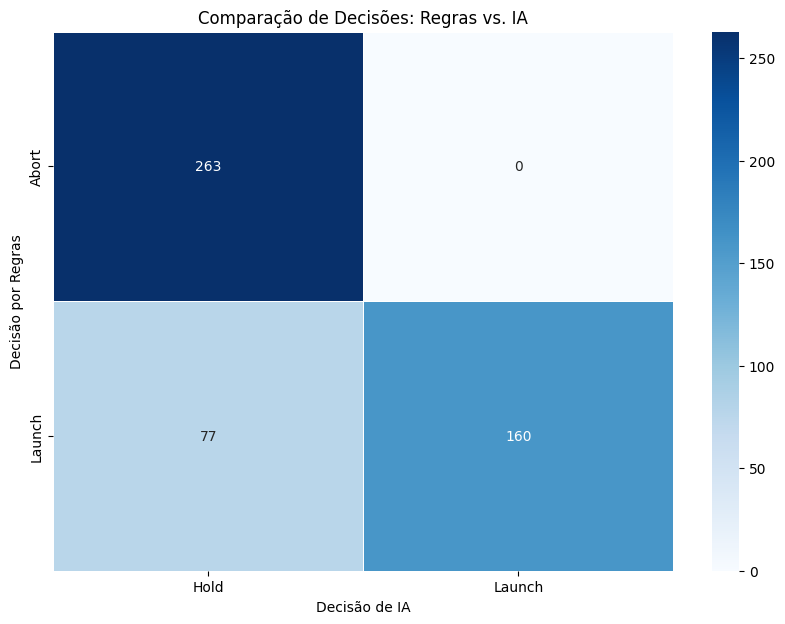

In [ ]:
comparison_matrix = pd.crosstab(telemetry_df_anomalies['launch_decision'], telemetry_df_anomalies['launch_decision_ia'], margins=True)

print("Matriz de Comparação entre Decisão por Regras e Decisão por IA:")
print(comparison_matrix)

plt.figure(figsize=(10, 7))
sns.heatmap(comparison_matrix.iloc[:-1, :-1], annot=True, fmt="d", cmap="Blues", linewidths=.5)
plt.title('Comparação de Decisões: Regras vs. IA')
plt.xlabel('Decisão de IA')
plt.ylabel('Decisão por Regras')
plt.show()


### Como Usar o Modelo de IA para Novas Predições

Este é um exemplo de como você pode usar o modelo treinado para prever a decisão de lançamento para novos dados de telemetria.

In [ ]:
# 1. Exemplo de Novos Dados de Telemetria (você os obteria de um sensor, arquivo, etc.)
# Estes dados devem seguir a mesma estrutura dos dados originais.

new_telemetry_data = pd.DataFrame({
    'internal_temp_c': [25.0, 38.0, 15.0, 28.0],
    'external_temp_c': [10.0, -5.0, 5.0, 30.0],
    'battery_voltage_v': [24.1, 21.5, 23.9, 24.5],
    'battery_current_a': [2.0, 3.5, 1.8, 1.2],
    'battery_soc_percent': [85, 70, 90, 78],
    'battery_capacity_ah': [120.0, 110.0, 125.0, 118.0],
    'power_load_kw': [0.7, 1.5, 0.6, 0.9],
    'energy_loss_percent': [2.5, 4.0, 1.0, 2.0],
    'tank_pressure_bar': [170.0, 150.0, 180.0, 185.0],
    'estimated_autonomy_min': [150, 80, 160, 130],
    'energy_available_kwh': [2.5, 1.8, 2.8, 2.3],
    'structural_integrity': ['OK', 'Compromised', 'OK', 'OK'],
    'critical_modules_status': ['Operational', 'Degraded', 'Operational', 'Operational'],
    'telemetry_link_status': ['Stable', 'Unstable', 'Stable', 'Stable']
})

print("Novos dados de telemetria:")
print(new_telemetry_data)


Novos dados de telemetria:
   internal_temp_c  external_temp_c  battery_voltage_v  battery_current_a  \
0             25.0             10.0               24.1                2.0   
1             38.0             -5.0               21.5                3.5   
2             15.0              5.0               23.9                1.8   
3             28.0             30.0               24.5                1.2   

   battery_soc_percent  battery_capacity_ah  power_load_kw  \
0                   85                120.0            0.7   
1                   70                110.0            1.5   
2                   90                125.0            0.6   
3                   78                118.0            0.9   

   energy_loss_percent  tank_pressure_bar  estimated_autonomy_min  \
0                  2.5              170.0                     150   
1                  4.0              150.0                      80   
2                  1.0              180.0                     160   


In [ ]:
# 2. Pré-processamento dos Novos Dados

# Aplicar One-Hot Encoding para as features categóricas
new_features_processed = pd.get_dummies(new_telemetry_data, columns=categorical_features, drop_first=True)

# Garantir que as colunas sejam as mesmas que as do treino e na mesma ordem
# Adicionar colunas ausentes (se houver alguma categoria que não apareceu nos novos dados)
missing_cols_in_new_data = set(X_train.columns) - set(new_features_processed.columns)
for c in missing_cols_in_new_data:
    new_features_processed[c] = 0

# Remover colunas extras nos novos dados que não estavam no treinamento (se houver)
extra_cols_in_new_data = set(new_features_processed.columns) - set(X_train.columns)
new_features_processed = new_features_processed.drop(columns=list(extra_cols_in_new_data))

# Garantir a ordem das colunas
new_features_processed = new_features_processed[X_train.columns]

print("\nNovos dados pré-processados para o modelo de IA:")
print(new_features_processed)



Novos dados pré-processados para o modelo de IA:
   internal_temp_c  external_temp_c  battery_voltage_v  battery_current_a  \
0             25.0             10.0               24.1                2.0   
1             38.0             -5.0               21.5                3.5   
2             15.0              5.0               23.9                1.8   
3             28.0             30.0               24.5                1.2   

   battery_soc_percent  battery_capacity_ah  power_load_kw  \
0                   85                120.0            0.7   
1                   70                110.0            1.5   
2                   90                125.0            0.6   
3                   78                118.0            0.9   

   energy_loss_percent  tank_pressure_bar  estimated_autonomy_min  \
0                  2.5              170.0                     150   
1                  4.0              150.0                      80   
2                  1.0              180.0     

In [ ]:
# 3. Fazer as Previsões com o Modelo Treinado
predictions_encoded_new = model.predict(new_features_processed)

# 4. Converter as Previsões de Volta para as Labels Originais
predictions_labels_new = le.inverse_transform(predictions_encoded_new)

# Adicionar as previsões de volta aos novos dados (ou exibi-las)
new_telemetry_data['launch_decision_ia'] = predictions_labels_new

print("\nPrevisões do Modelo de IA para os Novos Dados:")
print(new_telemetry_data[['internal_temp_c', 'external_temp_c', 'structural_integrity', 'critical_modules_status', 'telemetry_link_status', 'launch_decision_ia']])



Previsões do Modelo de IA para os Novos Dados:
   internal_temp_c  external_temp_c structural_integrity  \
0             25.0             10.0                   OK   
1             38.0             -5.0          Compromised   
2             15.0              5.0                   OK   
3             28.0             30.0                   OK   

  critical_modules_status telemetry_link_status launch_decision_ia  
0             Operational                Stable               Hold  
1                Degraded              Unstable               Hold  
2             Operational                Stable             Launch  
3             Operational                Stable               Hold  


### Carregando Outros Datasets CSV

Use o código abaixo para carregar um novo arquivo CSV. Você será solicitado a selecionar o arquivo.

In [ ]:
from google.colab import files
import pandas as pd

# Faz o upload do arquivo
uploaded = files.upload()

# Assume que o usuário enviará apenas um arquivo e pega o nome dele
for fn in uploaded.keys():
  print(f'User uploaded file "{fn}"')
  file_name = fn

# Carrega o DataFrame a partir do arquivo CSV enviado
# Adapte o nome da coluna 'timestamp' e o formato de data se for diferente
new_df = pd.read_csv(file_name)

# Tente converter a coluna 'timestamp' para datetime, se existir e for relevante
if 'timestamp' in new_df.columns:
    new_df['timestamp'] = pd.to_datetime(new_df['timestamp'], errors='coerce')

print(f"DataFrame '{file_name}' carregado com sucesso.")
print(new_df.head())

Saving telemetry_synthetic.csv to telemetry_synthetic.csv
User uploaded file "telemetry_synthetic.csv"
DataFrame 'telemetry_synthetic.csv' carregado com sucesso.
            timestamp  internal_temp_c  external_temp_c  battery_voltage_v  \
0 2025-01-01 00:00:00            28.87            -4.12              47.65   
1 2025-01-01 00:00:30            21.72            12.69              46.16   
2 2025-01-01 00:01:00            31.70            19.43              48.04   
3 2025-01-01 00:01:30            31.72            20.54              49.22   
4 2025-01-01 00:02:00            29.98            -3.40              47.37   

   battery_current_a  battery_soc_percent  battery_capacity_ah  \
0              42.32                89.46               107.07   
1              39.88                86.00               101.80   
2              35.55                98.29                93.46   
3             117.31                75.14               102.08   
4              48.94                63.

### Aplicando o Modelo de IA ao Novo Dataset (`new_df`)

Agora, vamos aplicar os mesmos passos de pré-processamento ao `new_df` que aplicamos ao conjunto de dados original e, em seguida, usaremos o modelo de IA treinado para fazer previsões de decisão de lançamento.

In [ ]:
# 1. Preparar o `new_df` para a predição
# Criar uma cópia para não modificar o original diretamente para o pré-processamento
new_df_processed = new_df.copy()

# Remover colunas que não são features ou que são o target original (como 'timestamp' e 'launch_decision')
# 'launch_decision' é a coluna que queremos prever, e 'timestamp' não é usada como feature.
# A coluna 'anomalia_inserida' não existe no new_df, então não precisamos removê-la.
columns_to_drop = ['timestamp', 'launch_decision']
new_df_processed = new_df_processed.drop(columns=columns_to_drop, errors='ignore')

# 2. Transformar as colunas booleanas/categóricas para corresponder ao formato de X_train
# Em X_train, tínhamos 'structural_integrity_OK', 'critical_modules_status_Operational', 'telemetry_link_status_Unstable'
# No new_df (telemetry_synthetic.csv), estas colunas são numéricas (0 ou 1).
# Precisamos mapeá-las corretamente.

# structural_integrity_OK: é 1 se structural_integrity no new_df é 1
new_df_processed['structural_integrity_OK'] = (new_df_processed['structural_integrity'] == 1).astype(int)
# critical_modules_status_Operational: é 1 se critical_modules_status no new_df é 1
new_df_processed['critical_modules_status_Operational'] = (new_df_processed['critical_modules_status'] == 1).astype(int)
# telemetry_link_status_Unstable: é 1 se telemetry_link_status no new_df é 0 (assumindo 1 é Stable)
new_df_processed['telemetry_link_status_Unstable'] = (new_df_processed['telemetry_link_status'] == 0).astype(int)

# Remover as colunas originais que foram transformadas
new_df_processed = new_df_processed.drop(columns=['structural_integrity', 'critical_modules_status', 'telemetry_link_status'])

# 3. Garantir que as colunas sejam as mesmas que as do treino (X_train) e na mesma ordem
# Adicionar colunas ausentes (se houver alguma que não apareceu nos novos dados) com valor 0
missing_cols_in_new_data = set(X_train.columns) - set(new_df_processed.columns)
for c in missing_cols_in_new_data:
    new_df_processed[c] = 0

# Remover colunas extras nos novos dados que não estavam no treinamento (se houver)
extra_cols_in_new_data = set(new_df_processed.columns) - set(X_train.columns)
new_df_processed = new_df_processed.drop(columns=list(extra_cols_in_new_data))

# Garantir a ordem das colunas
new_df_features_aligned = new_df_processed[X_train.columns]

print("Novo DataFrame pré-processado e alinhado para predição:")
display(new_df_features_aligned.head())


Novo DataFrame pré-processado e alinhado para predição:


,internal_temp_c,external_temp_c,battery_voltage_v,battery_current_a,battery_soc_percent,battery_capacity_ah,power_load_kw,energy_loss_percent,tank_pressure_bar,estimated_autonomy_min,energy_available_kwh,structural_integrity_OK,critical_modules_status_Operational,telemetry_link_status_Unstable
0,28.87,-4.12,47.65,42.32,89.46,107.07,22.84,2.52,116.10,49.02,4.5641,1,1,0
1,21.72,12.69,46.16,39.88,86.00,101.80,9.41,5.54,135.47,45.88,4.0412,1,1,0
2,31.70,19.43,48.04,35.55,98.29,93.46,6.85,2.58,137.37,126.50,4.4130,1,1,0
3,31.72,20.54,49.22,117.31,75.14,102.08,21.59,5.71,138.09,122.94,3.7753,1,1,0
4,29.98,-3.40,47.37,48.94,63.19,89.31,7.02,3.67,126.78,94.25,2.6733,1,1,0


In [ ]:
# 4. Fazer as Previsões com o Modelo Treinado
predictions_encoded_new_df = model.predict(new_df_features_aligned)

# 5. Converter as Previsões de Volta para as Labels Originais
predictions_labels_new_df = le.inverse_transform(predictions_encoded_new_df)

# Adicionar as previsões como uma nova coluna ao DataFrame original `new_df`
new_df['launch_decision_ia'] = predictions_labels_new_df

print("Previsões do Modelo de IA para o new_df adicionadas com sucesso!")
print("Primeiras linhas do new_df com a nova coluna 'launch_decision_ia':")
display(new_df.head())


Previsões do Modelo de IA para o new_df adicionadas com sucesso!
Primeiras linhas do new_df com a nova coluna 'launch_decision_ia':


,timestamp,internal_temp_c,external_temp_c,battery_voltage_v,battery_current_a,battery_soc_percent,battery_capacity_ah,energy_available_kwh,power_load_kw,energy_loss_percent,tank_pressure_bar,structural_integrity,critical_modules_status,telemetry_link_status,estimated_autonomy_min,launch_decision,launch_decision_ia
0,2025-01-01 00:00:00,28.87,-4.12,47.65,42.32,89.46,107.07,4.5641,22.84,2.52,116.10,1,1,1,49.02,READY,Hold
1,2025-01-01 00:00:30,21.72,12.69,46.16,39.88,86.00,101.80,4.0412,9.41,5.54,135.47,1,1,1,45.88,READY,Hold
2,2025-01-01 00:01:00,31.70,19.43,48.04,35.55,98.29,93.46,4.4130,6.85,2.58,137.37,1,1,1,126.50,READY,Hold
3,2025-01-01 00:01:30,31.72,20.54,49.22,117.31,75.14,102.08,3.7753,21.59,5.71,138.09,1,1,1,122.94,READY,Hold
4,2025-01-01 00:02:00,29.98,-3.40,47.37,48.94,63.19,89.31,2.6733,7.02,3.67,126.78,1,1,1,94.25,READY,Hold
